In [ ]:
# =============================================================================
# DDPM(Denoising Data Probabilistic Models) — destroy a photo with noise, then learn to undo it
# =============================================================================
#
# VAE: compress, then redraw (often blurry).
# GAN: forger vs detective (sharp, but drama to train).
# Diffusion (this notebook): take a real photo, slowly add static until it's
# TV snow, then train a net to walk BACKWARD: snow → almost-snow → photo.
#
# DDPM = Denoising Diffusion Probabilistic Model (Ho et al.).
# "Probabilistic" just means: at each step we treat noise as random, not
# one fixed recipe.
#
#
# ---------------------------------------------------------------------------
# 1) FORWARD DIFFUSION — hide the photo on purpose
# ---------------------------------------------------------------------------
# Imagine 1000 tiny sprinkles of Gaussian noise. After enough sprinkles
# you cannot tell it was a "7". That's the FORWARD process. Nobody trains
# this part. It's a fixed recipe.
#
#   t = 0        t = 200       t = 600        t = 1000 = T
#   clean 7  →  dusty 7   →  lumpy gray   →  pure static
#
# Why many small steps, not one giant blast?
#   Undoing one huge blast is hard. Undoing a pinch of noise is a homework
#   a neural net can actually learn.
#
# Math you will see later, in English:
#   beta_t  = "how much noise this step adds" (starts tiny, grows)
#   We can JUMP to any t in one shot (no loop of 1000 adds) using a closed
#   formula: mix the clean image with noise, with a recipe that depends on t.
#
#   x_t ≈  (still-a-bit-of-photo) * x_0  +  (how-much-static) * ε
#   where ε is random N(0,1) noise, same shape as the image.
#
#
# ---------------------------------------------------------------------------
# 2) REVERSE DIFFUSION — the learned "cleanup"
# ---------------------------------------------------------------------------
# Generation starts from pure static x_T and walks t = T, T-1, …, 1, 0.
# Each reverse step asks: "given this noisy picture and the time t,
# what did it look like one sprinkle ago?"
#
# The network does not have to output the full clean photo every time.
# DDPM's usual trick: predict the NOISE ε that was mixed in. If you know
# the noise, you can subtract a bit of it and get a slightly cleaner x.
#
#   snow + "I think the static looks like THIS"  →  slightly less snow
#
# Repeat ~T times. That's sampling.
#
#
# ---------------------------------------------------------------------------
# 3) TRAINING OBJECTIVE — one simple homework
# ---------------------------------------------------------------------------
# Pick a real photo x_0.
# Pick a random time t.
# Mix in noise ε to make x_t.
# Ask the net: "what noise was that?"
# Loss = how wrong was the guess (usually MSE between true ε and predicted ε).
#
# That's it. No discriminator. No KL neighborhood. Just "name the static."
#
# Why this equals "learn the reverse process":
#   If you can name the static at every t, you can peel it off. Peeling it
#   off IS the reverse chain.
#
#
# ---------------------------------------------------------------------------
# 4) U-NET — the brain that looks at noisy pixels
# ---------------------------------------------------------------------------
# Same family as pix2pix: down (wide view) then up (redraw), with SKIPS
# so fine speckle isn't lost.
#
# Extra for diffusion: the net must KNOW t. A "7" at t=10 is almost clean;
# at t=900 it's blizzard. We inject t with a time embedding (a vector that
# means "you are at step 347") added into the U-Net blocks.
#
#   noisy image x_t  +  time t  ──U-Net──▶  predicted noise ε̂
#
#
# ---------------------------------------------------------------------------
# 5) SAMPLING (generation)
# ---------------------------------------------------------------------------
# 1. Draw x_T = random static (same size as a photo).
# 2. For t = T down to 1:
#      ε̂ = U-Net(x_t, t)
#      peel a bit of ε̂ off x_t  →  x_{t-1}
#      (optional tiny extra noise, except at the last step)
# 3. x_0 is the generated digit.
#
# Slow vs GAN: GAN paints in ONE forward pass. DDPM paints in T passes.
# That's why people later invent fewer-step samplers. For learning, T=1000
# in the formula, even if we train a shorter demo.
#
#
# ---------------------------------------------------------------------------
# One table
# ---------------------------------------------------------------------------
#   Forward   destroy photo with a known noise recipe     (no learning)
#   Reverse   learned cleanup, one sprinkle at a time
#   Train     predict the noise that was added at random t
#   U-Net     image in, noise-guess out, conditioned on t
#   Sample    start from snow, peel T times
#
# Next cells: betas/alphas, a small U-Net, train on MNIST, sample digits.


In [11]:
# =============================================================================
# SETUP — photos, how many noise steps, how big the U-Net is
# =============================================================================
# timesteps T = 1000: recipe has 1000 sprinkles. Sampling then does 1000
# peels (slow on CPU). Training uses ONE random t per image, so T=1000 is OK.
# We still shorten epochs/batches so this laptop lesson finishes.
#

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

image_size = 32
channels = 1
batch_size = 128
epochs = 3          # CPU demo (20 full epochs is very slow)
max_batches = 40    # not all 60k images
lr = 1e-3
timesteps = 1000    # T in the DDPM formulas
beta_start = 1e-4   # first sprinkle is tiny
beta_end = 0.02     # last sprinkles are heavier
dim = 64            # U-Net base channels
dim_mults = (1, 2, 4, 8)  # 64, 128, 256, 512 as we go down

transform = transforms.Compose(
    [
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),  # [-1, 1] like the GAN notebook
    ]
)
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(
    train_data, batch_size=batch_size, shuffle=True, num_workers=0
)  # 0 = avoid Jupyter/macOS worker crashes
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=0)
print(f"Train samples: {len(train_data)}  |  Test samples: {len(test_data)}")
print(f"Demo train: {epochs} epochs × {max_batches} batches")


Using device: cpu
Train samples: 60000
Demo train: 3 epochs × 40 batches


In [12]:
# =============================================================================
# NOISE SCHEDULE — the FIXED forward recipe (not learned)
# =============================================================================
#
# beta_t = how much new static this step adds. Linear: tiny at t=0, bigger at T.
# alpha_t = 1 - beta_t = how much of the previous picture we KEEP.
# alphas_cumprod = \bar{alpha}_t = product of alphas up to t
#   = "how much of the ORIGINAL photo is still visible at time t"
#
# Jump to any t in one line (no 1000-loop):
#   x_t = sqrt(\bar{alpha}_t) * x_0  +  sqrt(1-\bar{alpha}_t) * ε
#
# The extra sqrt_recip_* and posterior_variance are for the REVERSE step later
# (peel predicted noise, maybe add a little fresh noise except at t=0).
#

def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, timesteps)


betas = linear_beta_schedule(timesteps).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
sqrt_recipm1_alphas_cumprod = torch.sqrt(1.0 / alphas_cumprod - 1)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

print(f"betas[0]={betas[0]:.6f}  betas[-1]={betas[-1]:.4f}")
print(f"signal left at t=0:  {alphas_cumprod[0]:.4f}  (almost the photo)")
print(f"signal left at t=T:  {alphas_cumprod[-1]:.4f}  (almost gone)")


betas[0]=0.000100  betas[-1]=0.0200
signal left at t=0:  0.9999  (almost the photo)
signal left at t=T:  0.0000  (almost gone)


In [13]:
# =============================================================================
# TIME EMBEDDING — tell the U-Net "you are at sprinkle t=347"
# =============================================================================
# A noisy 7 at t=10 is almost a 7. At t=900 it is blizzard. Same pixels,
# different job. We turn t into a vector of sines/cosines (Transformer-style)
# so nearby times look similar, far times look different.
#
# Out shape: [batch, dim]  e.g. [128, 128]
#

def sinusoidal_embedding(timesteps, dim):
    half_dim = dim // 2
    freqs = math.log(10000) / (half_dim - 1)
    freqs = torch.exp(torch.arange(half_dim, device=timesteps.device) * -freqs)
    args = timesteps[:, None].float() * freqs[None, :]
    return torch.cat((args.sin(), args.cos()), dim=1)


_t = torch.tensor([0, 10, 999], device=device)
_e = sinusoidal_embedding(_t, 128)
print(f"sinusoidal_embedding shape: {tuple(_e.shape)}  (want 3, 128)")


sinusoidal_embedding shape: (3, 128)  (want 3, 128)


In [14]:
# =============================================================================
# U-NET — noisy photo in, guessed noise out (and it knows t)
# =============================================================================
#
# BUGFIX (time dim): U-Net time_mlp used to end at 512 numbers, but each
# ResBlock expected 128 → (128×512) @ (128×64) crash. ResBlock now takes
# the expanded 512-D time vector.
#
# BUGFIX (skips): only save ResBlock maps as skips — NOT the stride-2
# downsample. Concatenating 8×8 with 4×4 is a size mismatch. Skips must
# match the spatial size of the matching up-block.
#
# ResBlock: conv, add "what time is it?", conv, residual sidewalk.
# U-Net: down (save skips) → middle → up (concat skips) → 1×1 conv.
#

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_mlp = nn.Linear(time_dim, out_ch)  # time_dim = 512 after U-Net mlp
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = F.silu(self.norm1(x))
        h = self.conv1(h)
        h = h + self.time_mlp(F.silu(t_emb))[:, :, None, None]  # broadcast over H,W
        h = F.silu(self.norm2(h))
        h = self.dropout(h)
        h = self.conv2(h)
        return h + self.shortcut(x)


class UNet(nn.Module):
    def __init__(
        self,
        in_channels=1,
        out_channels=1,
        dim=64,
        dim_mults=(1, 2, 4, 8),
        time_emb_dim=128,
    ):
        super().__init__()
        self.time_emb_dim = time_emb_dim
        time_dim = time_emb_dim * 4  # 128 → 512 inside the net

        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        self.init_conv = nn.Conv2d(in_channels, dim, 1)

        self.downs = nn.ModuleList([])
        in_ch = dim
        n_res = len(dim_mults)
        for i, mult in enumerate(dim_mults):
            out_ch = dim * mult
            for _ in range(2):
                self.downs.append(ResBlock(in_ch, out_ch, time_dim))
                in_ch = out_ch
            if i < n_res - 1:
                self.downs.append(nn.Conv2d(in_ch, in_ch, 4, stride=2, padding=1))

        mid_ch = dim * dim_mults[-1]
        self.mid_block1 = ResBlock(mid_ch, mid_ch, time_dim)
        self.mid_block2 = ResBlock(mid_ch, mid_ch, time_dim)

        self.ups = nn.ModuleList([])
        in_ch = mid_ch
        for i, mult in reversed(list(enumerate(dim_mults))):
            out_ch = dim * mult
            for _ in range(2):
                self.ups.append(ResBlock(in_ch + dim * mult, out_ch, time_dim))
                in_ch = out_ch
            if i > 0:
                self.ups.append(nn.ConvTranspose2d(in_ch, in_ch, 4, stride=2, padding=1))

        self.final_conv = nn.Conv2d(in_ch, out_channels, 1)

    def forward(self, x, t):
        t_emb = self.time_mlp(sinusoidal_embedding(t, self.time_emb_dim))

        x = self.init_conv(x)
        skips = []
        for layer in self.downs:
            if isinstance(layer, ResBlock):
                x = layer(x, t_emb)
                skips.append(x)  # same HxW as this level; used later on the way up
            else:
                x = layer(x)  # stride-2: shrink; do not skip (sizes would not match)

        x = self.mid_block1(x, t_emb)
        x = self.mid_block2(x, t_emb)

        skips = skips[::-1]
        for layer in self.ups:
            if isinstance(layer, ResBlock):
                skip = skips.pop(0)
                x = torch.cat([x, skip], dim=1)  # concat on channels
                x = layer(x, t_emb)
            else:
                x = layer(x)  # ConvTranspose: grow HxW back toward 32×32
        return self.final_conv(x)


# Shape check (this is the crash we just fixed)
_unet = UNet(in_channels=1, out_channels=1, dim=64, dim_mults=(1, 2, 4, 8)).to(device)
_x = torch.randn(2, 1, 32, 32, device=device)
_t = torch.randint(0, timesteps, (2,), device=device)
_y = _unet(_x, _t)
print(f"U-Net out: {tuple(_y.shape)}  (want same as input {tuple(_x.shape)})")
assert _y.shape == _x.shape


U-Net out: (2, 1, 32, 32)  (want same as input (2, 1, 32, 32))


In [15]:
# =============================================================================
# DDPM WRAPPER — add noise (q_sample), grade the guess (p_losses), peel (sample)
# =============================================================================
#
# q_sample: jump to time t in one mix of photo + ε
# p_losses: U-Net guesses ε, MSE vs true ε   ← THE train homework
# p_sample: one reverse step using that guess
# sample:   start from snow, p_sample T times
#
# register_buffer: store betas on the module (moves with .to(device), not trained)
#

class DDPM(nn.Module):
    def __init__(self, model, betas, timesteps=1000):
        super().__init__()
        self.model = model
        self.timesteps = timesteps
        self.register_buffer("betas", betas)
        self.register_buffer("alphas", 1.0 - betas)
        self.register_buffer("alphas_cumprod", torch.cumprod(self.alphas, dim=0))
        self.register_buffer(
            "alphas_cumprod_prev", F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)
        )
        self.register_buffer("sqrt_alphas_cumprod", torch.sqrt(self.alphas_cumprod))
        self.register_buffer(
            "sqrt_one_minus_alphas_cumprod", torch.sqrt(1.0 - self.alphas_cumprod)
        )
        self.register_buffer("sqrt_recip_alphas", torch.sqrt(1.0 / self.alphas))
        self.register_buffer(
            "sqrt_recipm1_alphas_cumprod", torch.sqrt(1.0 / self.alphas_cumprod - 1)
        )
        self.register_buffer(
            "posterior_variance",
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod),
        )

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        a = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        s = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        return a * x0 + s * noise, noise

    def p_losses(self, x0, t, noise=None):
        x_t, noise = self.q_sample(x0, t, noise)
        predicted = self.model(x_t, t)
        return F.mse_loss(predicted, noise)

    @torch.no_grad()
    def p_sample(self, x_t, t):
        b = self.betas[t].view(-1, 1, 1, 1)
        ra = self.sqrt_recip_alphas[t].view(-1, 1, 1, 1)
        som = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        pred_noise = self.model(x_t, t)
        mean = ra * (x_t - b * pred_noise / som)
        # Last reverse step (t=0): no extra noise — we want a clean photo.
        if t[0] > 0:
            var = self.posterior_variance[t].view(-1, 1, 1, 1)
            return mean + torch.sqrt(var) * torch.randn_like(x_t)
        return mean

    @torch.no_grad()
    def sample(self, shape, device, steps=None):
        """steps=None uses full T (slow). Use a smaller steps for a quick peek."""
        T = self.timesteps if steps is None else steps
        x = torch.randn(shape, device=device)
        # If steps < T, we still index the schedule at stretched times
        ts = torch.linspace(self.timesteps - 1, 0, T, device=device).long()
        for t in ts:
            t_tensor = torch.full((shape[0],), int(t.item()), device=device, dtype=torch.long)
            x = self.p_sample(x, t_tensor)
        return x


_ddpm = DDPM(_unet, betas, timesteps).to(device)
_loss = _ddpm.p_losses(_x, _t)
print(f"sanity p_losses: {_loss.item():.4f}  (just a random-net number)")


sanity p_losses: 1.4569  (just a random-net number)


Starting Training...
(demo 3 epochs × 40 batches)
Epoch 1/3 | Batch 0/40 | Loss: 1.0926
Epoch 1/3 | Batch 10/40 | Loss: 0.2463
Epoch 1/3 | Batch 20/40 | Loss: 0.1540
Epoch 1/3 | Batch 30/40 | Loss: 0.1201
Epoch 1 average loss: 0.3255
Epoch 2/3 | Batch 0/40 | Loss: 0.1185
Epoch 2/3 | Batch 10/40 | Loss: 0.0750
Epoch 2/3 | Batch 20/40 | Loss: 0.0733
Epoch 2/3 | Batch 30/40 | Loss: 0.0628
Epoch 2 average loss: 0.0819
Epoch 3/3 | Batch 0/40 | Loss: 0.0673
Epoch 3/3 | Batch 10/40 | Loss: 0.0666
Epoch 3/3 | Batch 20/40 | Loss: 0.0484
Epoch 3/3 | Batch 30/40 | Loss: 0.0510
Epoch 3 average loss: 0.0619
Training completed.


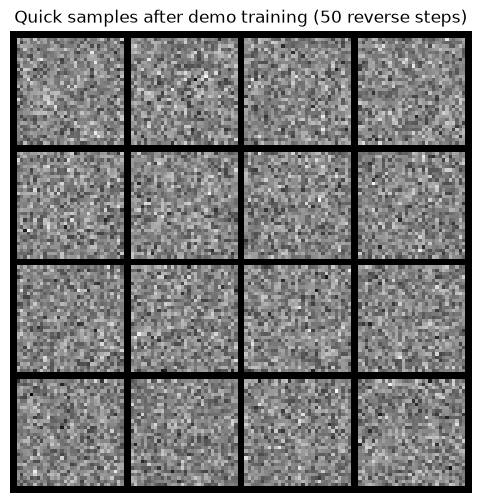

DDPM(
  (model): UNet(
    (time_mlp): Sequential(
      (0): Linear(in_features=128, out_features=512, bias=True)
      (1): SiLU()
      (2): Linear(in_features=512, out_features=512, bias=True)
    )
    (init_conv): Conv2d(1, 64, kernel_size=(1, 1), stride=(1, 1))
    (downs): ModuleList(
      (0-1): 2 x ResBlock(
        (norm1): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm2): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (time_mlp): Linear(in_features=512, out_features=64, bias=True)
        (shortcut): Identity()
      )
      (2): Conv2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ResBlock(
        (norm1): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
        (conv1): Conv2d(64, 128, kernel_size=(3,

In [16]:
# =============================================================================
# TRAIN — pick random t, hide the photo, grade the noise guess
# =============================================================================
# Sampling 64 images × 1000 peels every 5 epochs would dominate CPU time.
# Demo: 3×40 batches, one small sample grid at the end using fewer peels.
#

model = UNet(
    in_channels=channels, out_channels=channels, dim=dim, dim_mults=dim_mults
).to(device)
ddpm = DDPM(model, betas, timesteps).to(device)
optimizer = optim.Adam(ddpm.parameters(), lr=lr)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

print("Starting Training...")
print(f"(demo {epochs} epochs × {max_batches} batches)")
for epoch in range(epochs):
    total_loss = 0.0
    n_seen = 0
    for i, (x, _) in enumerate(train_loader):
        if i >= max_batches:
            break
        x = x.to(device)
        bsz = x.size(0)
        t = torch.randint(0, timesteps, (bsz,), device=device, dtype=torch.long)

        loss = ddpm.p_losses(x, t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * bsz
        n_seen += bsz
        if i % 10 == 0:
            print(
                f"Epoch {epoch+1}/{epochs} | Batch {i}/{max_batches} | Loss: {loss.item():.4f}"
            )

    print(f"Epoch {epoch+1} average loss: {total_loss / max(n_seen, 1):.4f}")
    scheduler.step()

print("Training completed.")

# Quick peek (50 peels, 16 images) — not full T=1000
ddpm.eval()
with torch.no_grad():
    samples = ddpm.sample((16, channels, image_size, image_size), device, steps=50)
samples = (samples + 1) / 2
plt.figure(figsize=(6, 6))
plt.axis("off")
plt.title("Quick samples after demo training (50 reverse steps)")
plt.imshow(np.transpose(vutils.make_grid(samples.cpu(), nrow=4, padding=2, normalize=True), (1, 2, 0)))
plt.show()
ddpm.train()

# ---------------------------------------------------------------------------
# HOW TO READ
# ---------------------------------------------------------------------------
# Loss: MSE on noise. Random start ~1.0. Falling toward 0.2–0.5 is learning.
# Quick 50-step grid will look mushy vs a full 1000-step sample after more
# epochs. That's time vs quality, not a broken U-Net.


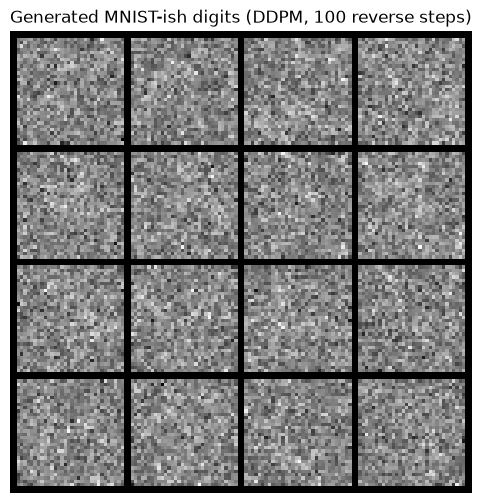

In [17]:
# =============================================================================
# SAMPLE — start from snow, peel (fewer steps = faster, softer digits)
# =============================================================================
# Full T=1000 × 64 images is a long CPU wait. Default here: 16 images, 100 steps.
#

ddpm.eval()
with torch.no_grad():
    samples = ddpm.sample((16, channels, image_size, image_size), device, steps=100)
samples = (samples + 1) / 2
plt.figure(figsize=(6, 6))
plt.axis("off")
plt.title("Generated MNIST-ish digits (DDPM, 100 reverse steps)")
plt.imshow(
    np.transpose(vutils.make_grid(samples.cpu(), nrow=4, padding=2, normalize=True), (1, 2, 0))
)
plt.show()

# ---------------------------------------------------------------------------
# HOW TO READ
# ---------------------------------------------------------------------------
# After the short demo: blobs / fuzzy digits are OK.
# Sharper 7s need more epochs + closer to T=1000 peels (and patience).


Test digit label: 7  (we hide it, then try to peel the snow)


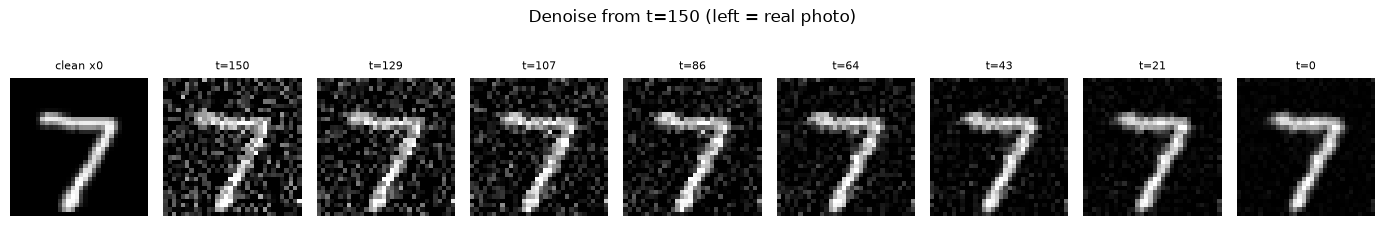

Same digit, two damage levels (t=40 dusty, t=150 heavier)…


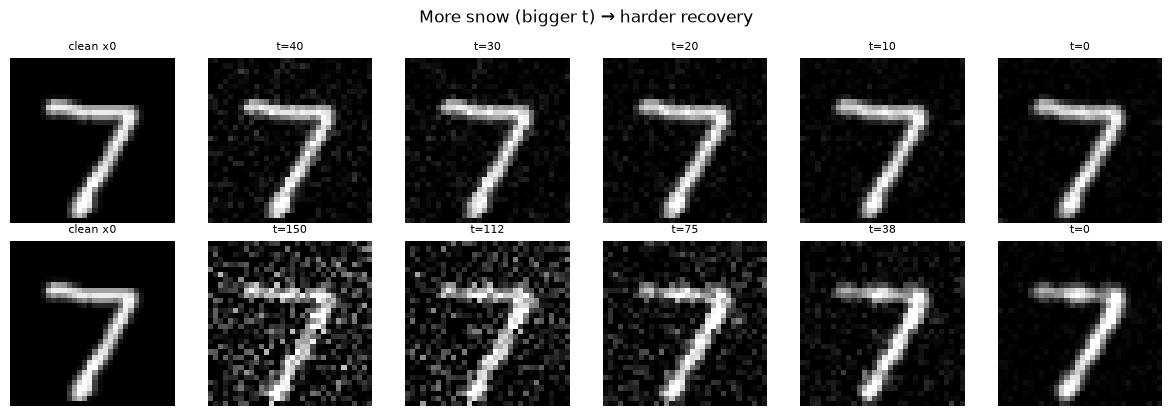

Interpolating noisy digits 7 → 2 at t=80, then peeling…


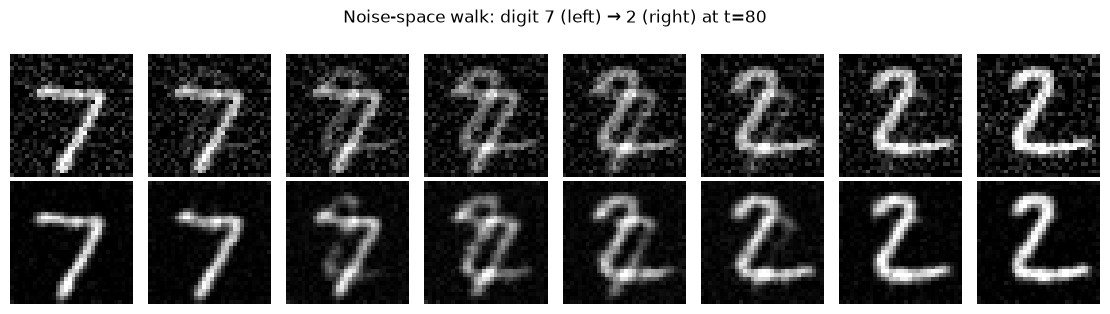

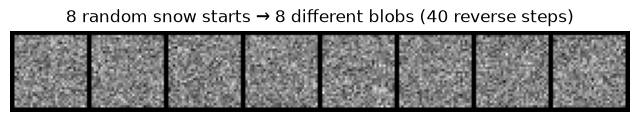

DDPM(
  (model): UNet(
    (time_mlp): Sequential(
      (0): Linear(in_features=128, out_features=512, bias=True)
      (1): SiLU()
      (2): Linear(in_features=512, out_features=512, bias=True)
    )
    (init_conv): Conv2d(1, 64, kernel_size=(1, 1), stride=(1, 1))
    (downs): ModuleList(
      (0-1): 2 x ResBlock(
        (norm1): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm2): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (time_mlp): Linear(in_features=512, out_features=64, bias=True)
        (shortcut): Identity()
      )
      (2): Conv2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ResBlock(
        (norm1): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
        (conv1): Conv2d(64, 128, kernel_size=(3,

In [20]:
# =============================================================================
# MINI-PROJECT — peel one photo, then morph in snow-space
# =============================================================================
#
# 1) Take a REAL test digit, hide it at time t, then run the reverse chain
#    and snapshot a few frames (static → less static).
# 2) Diffusion has no VAE "4-number zip". We interpolate two noisy pictures
#    at a fixed t, then peel the whole row together.
# 3) Different random snow → different recovered blobs (diversity).
#
# test_loader: MNIST test set (same 32×32, [-1,1] transform as training).
# Created here too so this cell still runs if you skipped re-running Setup.
#

test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=0)


def to_gray01(x):
    """Network pixels are [-1, 1]. Matplotlib gray wants [0, 1]."""
    return ((x.detach().squeeze().cpu() + 1) / 2).clamp(0, 1).numpy()


@torch.no_grad()
def reverse_from_t(ddpm, x_t, t_start):
    """Peel from t_start down to 0. x_t may be a batch."""
    x = x_t
    for t in reversed(range(int(t_start) + 1)):
        t_b = torch.full((x.size(0),), t, device=x.device, dtype=torch.long)
        x = ddpm.p_sample(x, t_b)
    return x


@torch.no_grad()
def denoise_snapshots(ddpm, x0, t_start, n_show=8):
    """
    Hide x0 at t_start, then reverse EVERY step (true DDPM peel).
    We only KEEP n_show frames so the plot stays readable.
    """
    t_start = int(t_start)
    t0 = torch.full((x0.size(0),), t_start, device=x0.device, dtype=torch.long)
    x_t, _ = ddpm.q_sample(x0, t0)

    show_ts = set(torch.linspace(t_start, 0, n_show).round().long().tolist())
    frames = [("clean x0", x0.clone())]
    x = x_t
    for t in reversed(range(t_start + 1)):
        if t in show_ts:
            frames.append((f"t={t}", x.clone()))
        t_b = torch.full((x.size(0),), t, device=x.device, dtype=torch.long)
        x = ddpm.p_sample(x, t_b)
    if frames[-1][0] != "t=0":
        frames.append(("recovered", x.clone()))
    return frames


@torch.no_grad()
def reverse_skipped(ddpm, x, steps=40):
    """Faster peel: jump along the T→0 schedule (same idea as ddpm.sample)."""
    ts = torch.linspace(ddpm.timesteps - 1, 0, steps, device=x.device).long()
    for t in ts:
        t_b = torch.full((x.size(0),), int(t.item()), device=x.device, dtype=torch.long)
        x = ddpm.p_sample(x, t_b)
    return x


def show_frame_row(frames, title):
    n = len(frames)
    fig, axes = plt.subplots(1, n, figsize=(n * 1.55, 2.1))
    if n == 1:
        axes = [axes]
    for ax, (label, img) in zip(axes, frames):
        ax.imshow(to_gray01(img), cmap="gray")
        ax.set_title(label, fontsize=8)
        ax.axis("off")
    fig.suptitle(title, y=1.08)
    plt.tight_layout()
    plt.show()


ddpm.eval()

# ---------------------------------------------------------------------------
# 1) Reverse-process movie for ONE test digit
# ---------------------------------------------------------------------------
# t_start=150 is "quite dusty" but not full blizzard. t=500 is 500 U-Net
# calls on CPU — skip that until you have a GPU or a longer-trained net.
#
x0, y0 = next(iter(test_loader))
x0 = x0[0:1].to(device)
print(f"Test digit label: {int(y0[0])}  (we hide it, then try to peel the snow)")

t_start = 150
frames = denoise_snapshots(ddpm, x0, t_start, n_show=8)
show_frame_row(frames, f"Denoise from t={t_start} (left = real photo)")

# Light vs heavy snow on the SAME photo
print("Same digit, two damage levels (t=40 dusty, t=150 heavier)…")
fig, axes = plt.subplots(2, 6, figsize=(12, 4.2))
for row, t_s in enumerate((40, 150)):
    fr = denoise_snapshots(ddpm, x0, t_s, n_show=5)
    # clean + 5 snapshots → 6 panels
    for col, (label, img) in enumerate(fr[:6]):
        axes[row, col].imshow(to_gray01(img), cmap="gray")
        axes[row, col].set_title(label, fontsize=8)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(f"start t={t_s}", fontsize=9)
plt.suptitle("More snow (bigger t) → harder recovery")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 2) Interpolate two NOISY images at a fixed t, peel the row as one batch
# ---------------------------------------------------------------------------
# Not a VAE latent. We blend pixels of x_t, then the U-Net has to clean
# a picture that was never a real digit — middle frames often go mushy.
#
imgs, labels = next(iter(test_loader))
xa, xb = imgs[0:1].to(device), imgs[1:1 + 1].to(device)
la, lb = int(labels[0]), int(labels[1])
t_mix = 80
t_b = torch.full((1,), t_mix, device=device, dtype=torch.long)
xta, _ = ddpm.q_sample(xa, t_b)
xtb, _ = ddpm.q_sample(xb, t_b)

n_mix = 8
a = torch.linspace(0, 1, n_mix, device=device).view(n_mix, 1, 1, 1)
x_mix = (1 - a) * xta + a * xtb  # [8, 1, 32, 32]
print(f"Interpolating noisy digits {la} → {lb} at t={t_mix}, then peeling…")
recovered = reverse_from_t(ddpm, x_mix, t_mix)

fig, axes = plt.subplots(2, n_mix, figsize=(n_mix * 1.4, 3.2))
for i in range(n_mix):
    axes[0, i].imshow(to_gray01(x_mix[i]), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(to_gray01(recovered[i]), cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("noisy mix", fontsize=9)
axes[1, 0].set_ylabel("after peel", fontsize=9)
plt.suptitle(f"Noise-space walk: digit {la} (left) → {lb} (right) at t={t_mix}")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 3) Diversity — different starting snow, same reverse recipe
# ---------------------------------------------------------------------------
z = torch.randn(8, channels, image_size, image_size, device=device)
diverse = reverse_skipped(ddpm, z, steps=40)
plt.figure(figsize=(8, 2.4))
plt.axis("off")
plt.title("8 random snow starts → 8 different blobs (40 reverse steps)")
plt.imshow(
    np.transpose(vutils.make_grid(diverse.cpu(), nrow=8, padding=2, normalize=True), (1, 2, 0))
)
plt.show()

ddpm.train()

# ---------------------------------------------------------------------------
# HOW TO READ
# ---------------------------------------------------------------------------
# Denoise row: left is the real test digit. Next is blizzard at t_start.
# Frames should get *less* noisy. After a 3-epoch demo they stay fuzzy —
# the U-Net barely learned "what snow looks like," not a sharp 7.
#
# Two damage levels: t=40 should look closer to the original than t=150.
#
# Interpolation: left recovered ~ first digit, right ~ second. The middle
# is a blend the model never saw. Gray mush there is normal.
#
# Diversity grid: if all 8 look identical, something is stuck. Different
# mush is already "the prior has more than one mode."
